In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:
#Load the dataset
df=pd.read_csv("housing_data.csv")

print(df.head(10))

      MedInc  HouseAge  AveRooms  AveOccup   Latitude   Longitude  \
0   9.771689         2         5         4  34.620502 -116.767052   
1  13.436604         6        10         7  32.801935 -123.516200   
2   9.229272        36         4         7  34.594186 -118.312710   
3   0.594232        52         3         7  35.732380 -122.867465   
4   5.380621         6         7         2  35.910304 -120.888465   
5   1.130031        30         9         2  41.744600 -120.525389   
6  12.526368        40         6         4  39.193432 -124.018844   
7   4.696125         6         4         2  36.111199 -119.739192   
8   2.858484        23         4         5  39.167293 -117.322750   
9   9.707185        35         4         3  36.891472 -121.665548   

           Price  
0  615254.398742  
1  812096.289339  
2  572406.645668  
3  135432.907221  
4  376483.136722  
5  204705.613127  
6  701108.227565  
7  363217.292664  
8  186564.450958  
9  608398.367962  


In [4]:
#Summary of the dataset
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MedInc     1000 non-null   float64
 1   HouseAge   1000 non-null   int64  
 2   AveRooms   1000 non-null   int64  
 3   AveOccup   1000 non-null   int64  
 4   Latitude   1000 non-null   float64
 5   Longitude  1000 non-null   float64
 6   Price      1000 non-null   float64
dtypes: float64(4), int64(3)
memory usage: 54.8 KB


,MedInc,HouseAge,AveRooms,AveOccup,Latitude,Longitude,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.580487,27.362000,5.528000,4.390000,37.219438,-119.212072,481823.685996
std,4.130566,14.922722,2.839944,2.266062,2.713258,2.924325,211484.624836
min,0.510438,1.000000,1.000000,1.000000,32.506421,-124.496984,63173.762865
25%,3.937061,15.000000,3.000000,2.000000,34.838806,-121.619962,301303.045100
50%,7.576421,28.000000,6.000000,4.000000,37.231203,-119.140153,485369.007251
75%,11.041972,41.000000,8.000000,6.000000,39.613300,-116.704491,649713.997341
max,14.984084,52.000000,10.000000,8.000000,41.994049,-114.007534,921457.942613


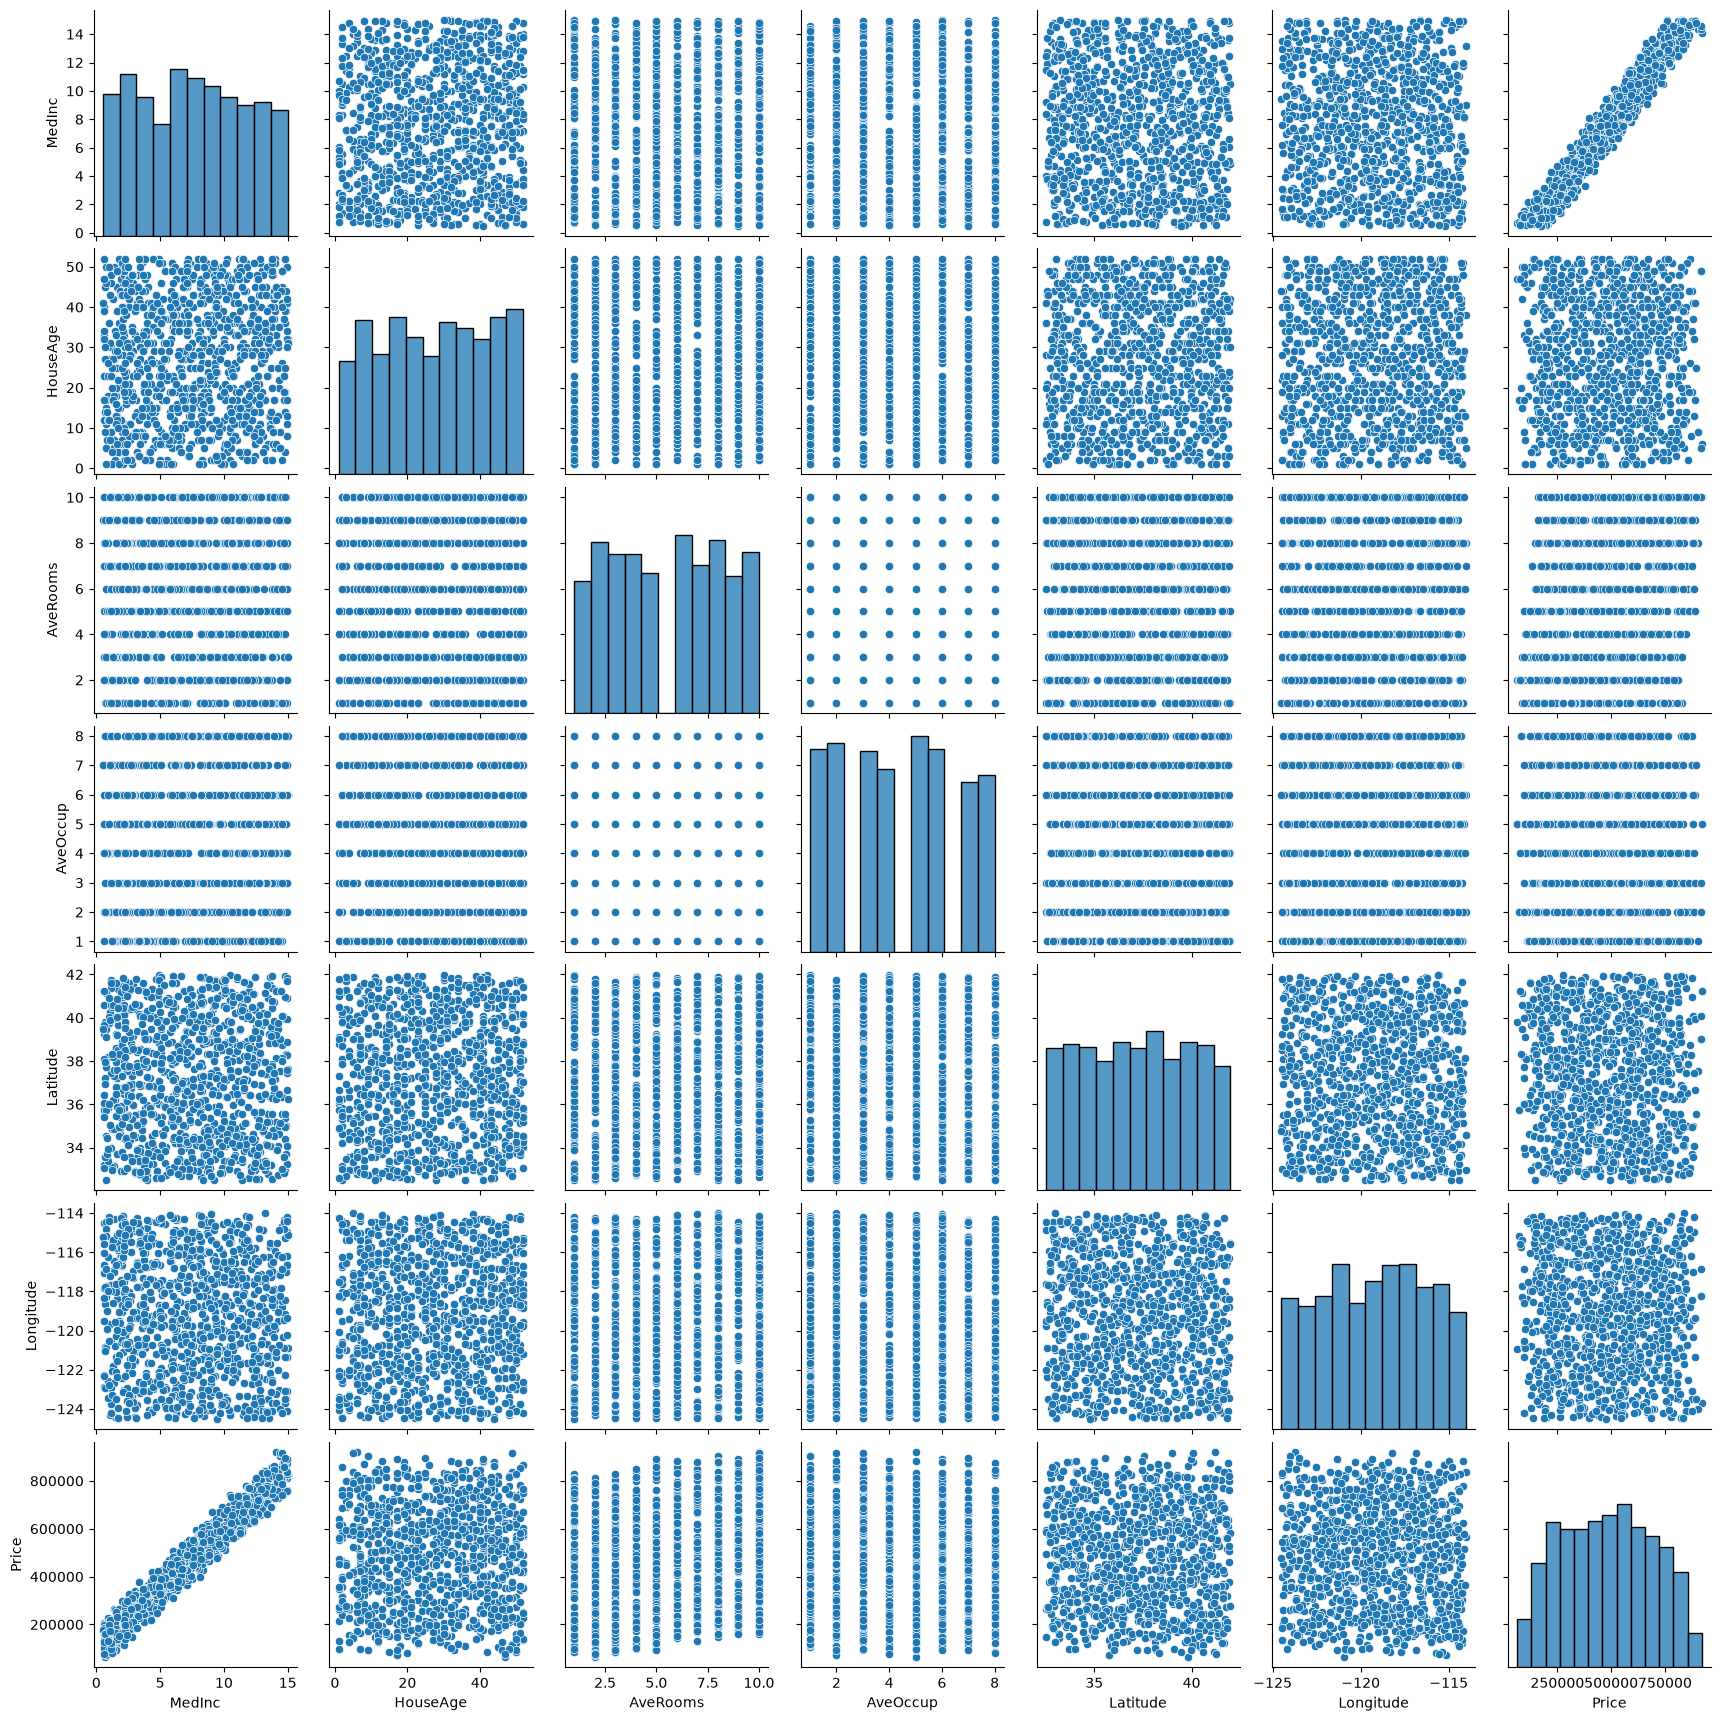

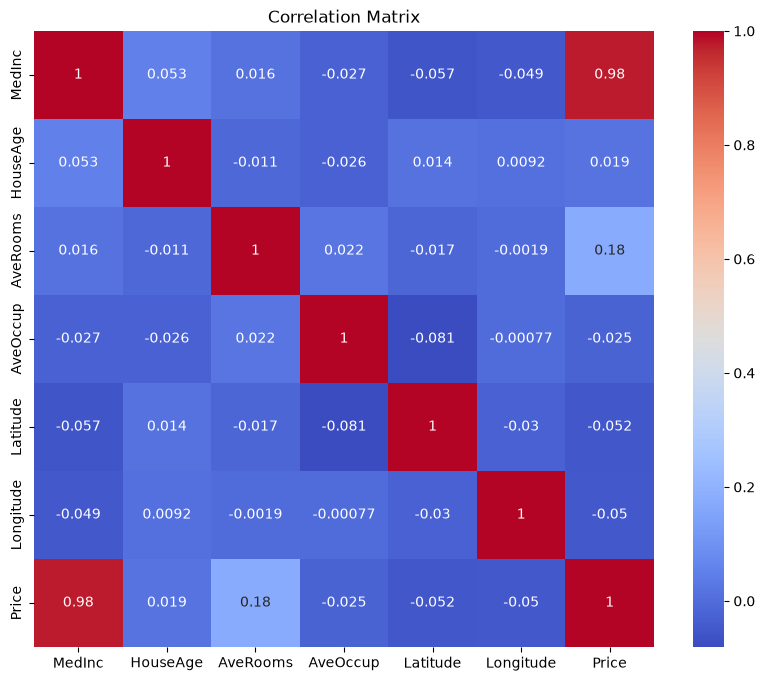

In [5]:
sns.pairplot(df)
plt.show()

correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True ,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

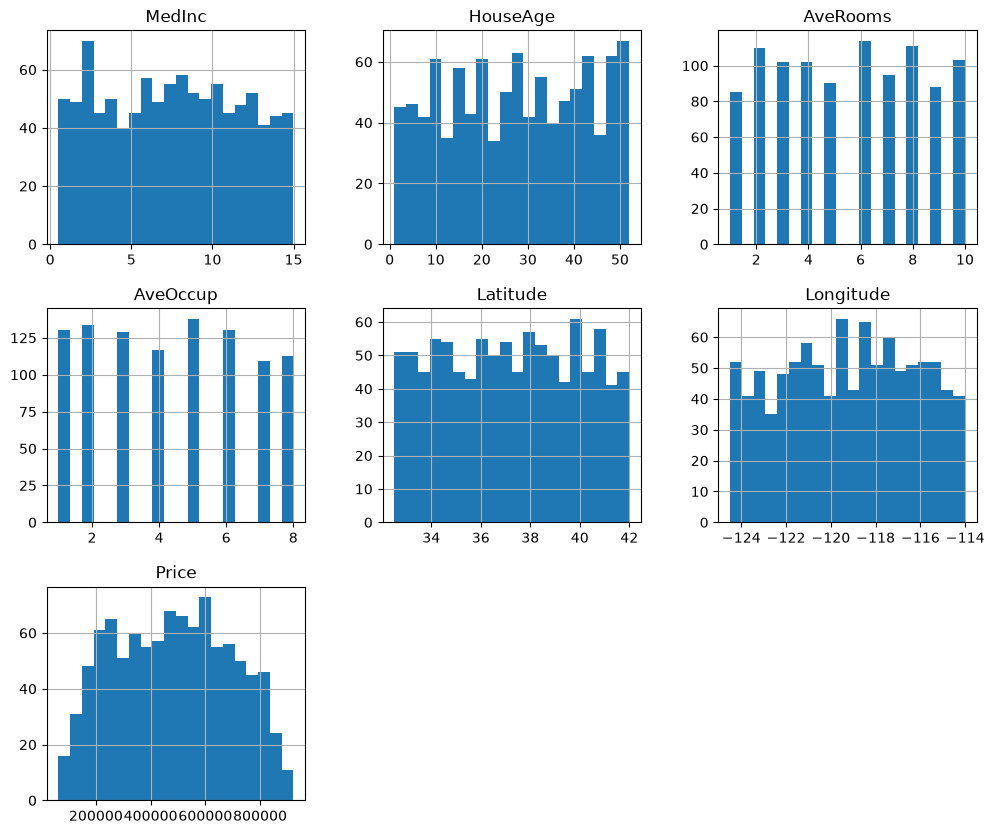

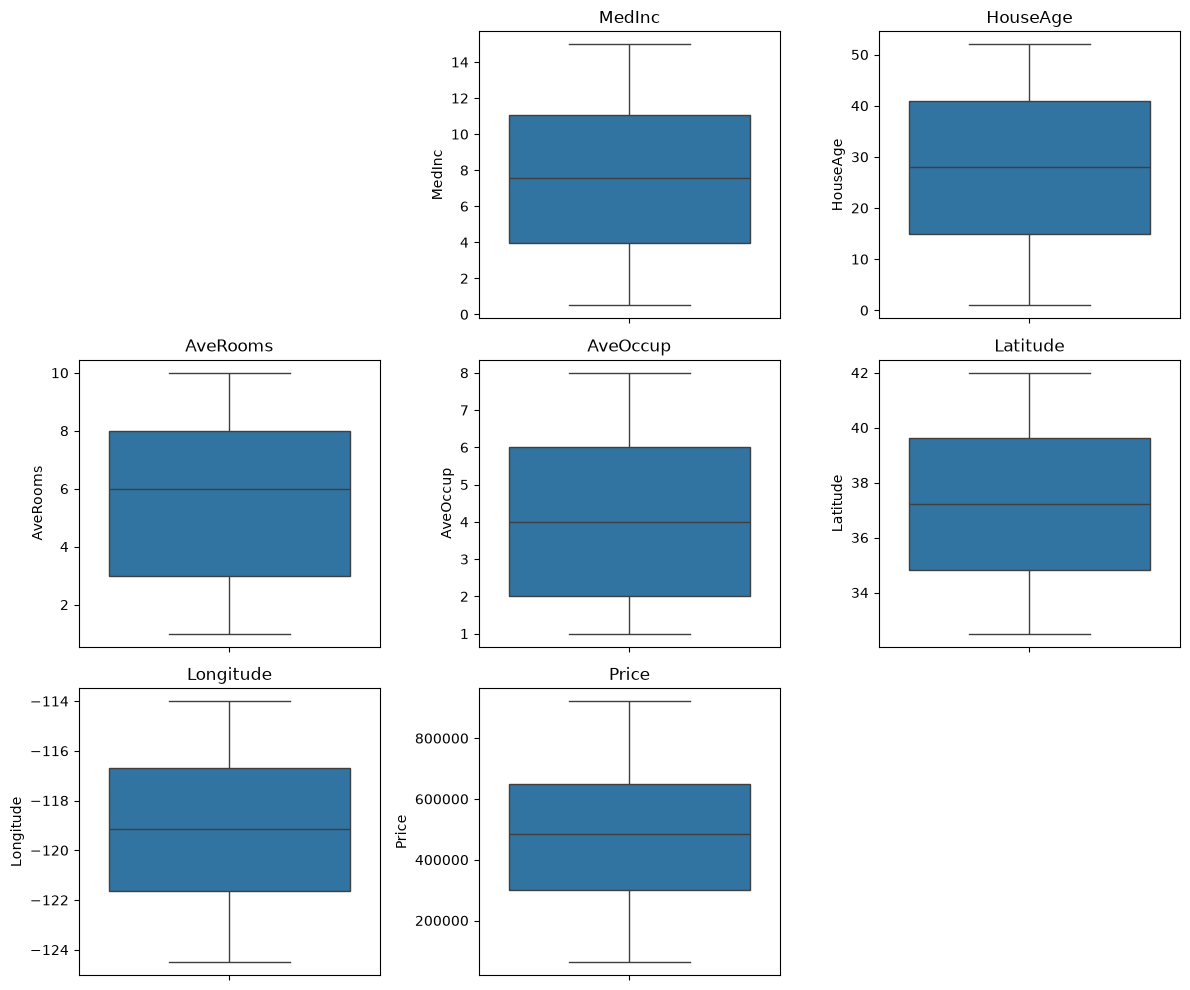

In [6]:
df.hist(figsize=(12,10), bins=20)
plt.show()

plt.figure(figsize=(12,10))
for i, column in enumerate(df.columns, 1):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[column])
    plt.title(column)
plt.tight_layout()
plt.show()

**Simple Linear Regression**

In [7]:
X=df[['MedInc']] #Predictor
y=df[['Price']] #Target



In [8]:
#Splitting the dataset into training and testing sets

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
#Create and train the model

simple_model=LinearRegression()
simple_model.fit(X_train, y_train) #fit the model to the training data


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[50056.96]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['MedInc']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[102711.87]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
# Predicting the target variable for the test set
y_pred = simple_model.predict(X_test)

#Evaluating the model
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"R Squared: {r2_score(y_test, y_pred)}")

Mean Squared Error: 2096264060.3929353
R Squared: 0.9489744061056672


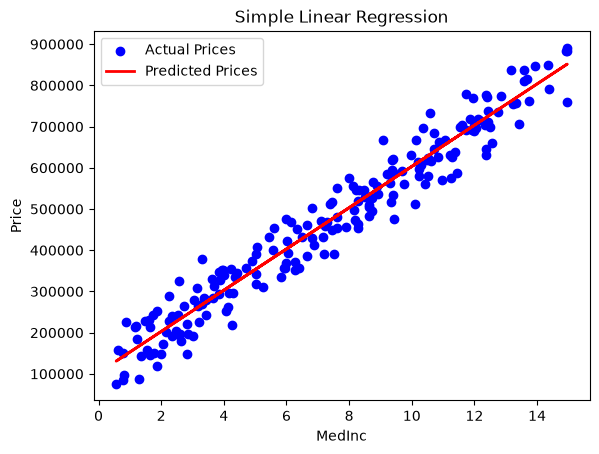

In [11]:
#Plot the regression line

plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted Prices')
plt.xlabel('MedInc')
plt.ylabel('Price')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()

In [20]:
#Input a new value for MedInc and predict the corresponding Price

new_data = np.array([[8.6]])#Enter a new value for MedInc here
prediction = simple_model.predict(new_data)

print(f"The predicted Price for MedInc value {new_data[0][0]} is: {prediction[0][0]}")

The predicted Price for MedInc value 8.6 is: 533201.7175160709
